In [1]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
from openai import OpenAI
from litellm import completion
from IPython.display import display
load_dotenv(override=True)


True

In [2]:
hf_token = os.environ['HF_TOKEN']

login(hf_token, add_to_git_credential=True)

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


# Load dataset from Huggingface

In [3]:
data_set = load_dataset("Shopify/product-catalogue")



In [6]:
train_ds = data_set['train']
holdout_ds = data_set['test']

split_ds = holdout_ds.train_test_split(test_size=0.5, seed=42)
test_ds = split_ds['train']
validation_ds = split_ds['test']


print(f"Number of training examples: {len(train_ds)}")
print(f"Number of test examples: {len(test_ds)}")
print(f"Number of validation examples: {len(validation_ds)}")


Number of training examples: 38631
Number of test examples: 4829
Number of validation examples: 4829


## Example of an data point

Full data point example:
{'product_title': 'Airplane Piggy Bank', 'product_description': 'The sweetest gift!', 'product_image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=785x734 at 0x139355AF0>, 'potential_product_categories': ['Toys & Games > Toys > Flying Toys', 'Home & Garden > Decor > Piggy Banks & Money Jars', 'Toys & Games > Toys > Flying Toys > Model Aircrafts', 'Arts & Entertainment > Hobbies & Creative Arts > Arts & Crafts > Art & Crafting Materials > Pottery & Sculpting Materials > Clay & Modeling Dough > Clay > Sculpting Clay', 'Toys & Games > Toys > Beach & Sand Toys > Sand Castle Molds', 'Hardware > Tools > Dollies & Hand Trucks', 'Home & Garden > Decor > Piggy Banks & Money Jars > Piggy Banks', 'Toys & Games > Toys > Play Vehicles > Toy Airplanes'], 'ground_truth_brand': 'Child to Cherish', 'ground_truth_is_secondhand': False, 'ground_truth_category': 'Home & Garden > Decor > Piggy Banks & Money Jars > Piggy Banks'}
Ground truth category: Home & Garden > Hous

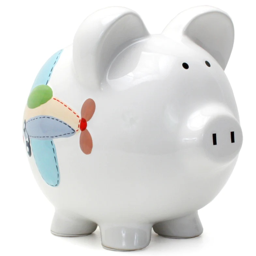

In [8]:
print("Full data point example:")
print(train_ds[0])
print("Ground truth category:", test_ds[0]["ground_truth_category"])
img = train_ds[0]["product_image"]
display(img.resize((256, 256)))

## Collect the top level categories from training data

One can run the following block of code for the first time to automatically collect the cateogories from *trainning data set* . Alternatively, if the list of categories readily available, skip to the next block of code.

In [10]:
#extract top level category from the ground truth category
# def top_level_category_extractor(example):
#     top_lev = example['ground_truth_category'].split(' > ')[0]
#     return top_lev

# top_level_list = set([top_level_category_extractor(example) for example in train_ds])

In [9]:
top_level_list = {'Bundles', 'Food, Beverages & Tobacco', 'Product Add-Ons', 'Gift Cards', 'Hardware', 'Home & Garden', 'Sporting Goods', 'Electronics', 'Baby & Toddler', 'Uncategorized', 'Apparel & Accessories', 'Furniture', 'Media', 'Toys & Games', 'Religious & Ceremonial', 'Luggage & Bags', 'Cameras & Optics', 'Arts & Entertainment', 'Software', 'Office Supplies', 'Animals & Pet Supplies', 'Vehicles & Parts', 'Health & Beauty', 'Business & Industrial', 'Services'}


# Exploring data set

#### Item with longest product description

In [ ]:
longest_item_description = None
max_len = 0
for item in train_ds:
    desc_len = len(item['product_description'])
    if desc_len > max_len:
        max_len = desc_len
        longest_item_description = item

print("Longest product description item:")
print(longest_item_description['product_description'])



Longest product description item:
USA Seller, Ship Fast! Adjustable Unique Bidirectional Support: Dual adjustment elastic straps provide customized fit and compression for all day comfort. Professional Grade Material:Lightweight, breathable and adjustable comfort fit with elasticated stretch that won't roll, slide or slip down, enhance circulation & oxygenation of the blood thereby increasing muscle performance & accelerate recovery of injured muscles, joints & much more. Pain Relief & Promotes Muscle/Joint Recovery: Compression is proven to Promote muscle recovery and injury prevention, our knee sleeve relieves muscle stiffness, extra soreness and offers rejuvenating relief from arthritis, osteoporosis, pain & discomfort, allowing you to perform at your peak in all situations. Suitable for Any Sports: Our knee brace delivers targeted compression with moderate support for knees. The best knee support sleeve and knee stabilizer for running, athletics, jogging, cycling, weightlifting, sq

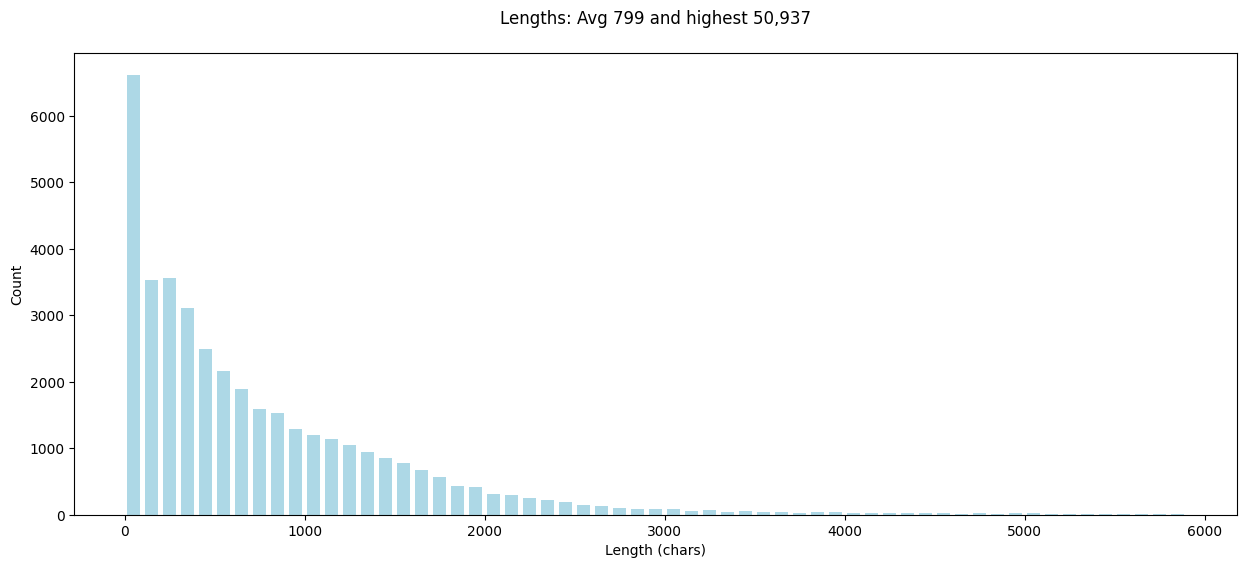

In [22]:
lengths = [len(item['product_description']) for item in train_ds]
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 6000, 100))
plt.show()

#### Item with longest product title

In [21]:
longest_item_title = None
max_len = 0
for item in train_ds:
    desc_len = len(item['product_title'])
    if desc_len > max_len:
        max_len = desc_len
        longest_item_title = item

print("Longest product title item:")
print(longest_item_title['product_title'])

Longest product title item:
Leak Diverters; Diverter Type: Roof Leak Diverter; Shape: Square; Length (Feet): 10.00; Width (Feet): 10; Material: Polyethylene; Thickness (mil): 10 mil; Height (Inch): 0.01 in; Height (Feet): 0.01 in; Thickness: 10 mil; Overall Length: 10.00; Overall He


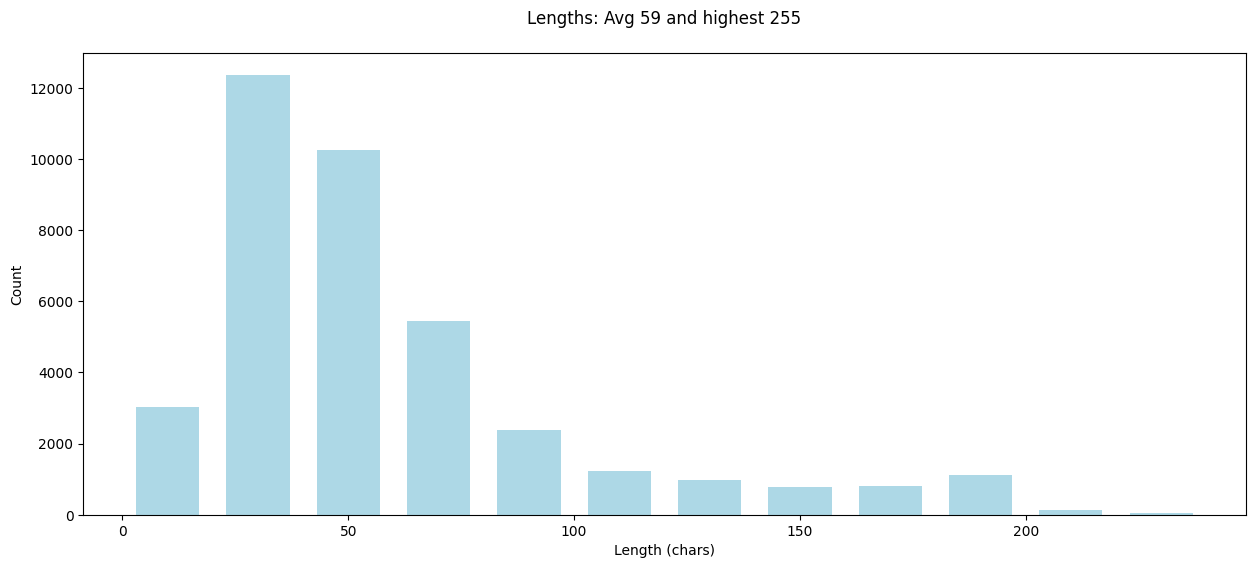

In [24]:
lengths = [len(item['product_title']) for item in train_ds]
plt.figure(figsize=(15, 6))
plt.title(f"Lengths: Avg {sum(lengths)/len(lengths):,.0f} and highest {max(lengths):,}\n")
plt.xlabel('Length (chars)')
plt.ylabel('Count')
plt.hist(lengths, rwidth=0.7, color="lightblue", bins=range(0, 255, 20))
plt.show()

# Cleaning up data and push to HuggingFace

In [ ]:
username = "leearum95"
# full = f"{username}/items_raw_full"
# lite = f"{username}/items_raw_lite"

# train = sample[:800_000]
# val = sample[800_000:810_000]
# test = sample[810_000:]

# Item.push_to_hub(full, train, val, test)

# train_lite = train[:20_000]
# val_lite = val[:1_000]
# test_lite = test[:1_000]

# Item.push_to_hub(lite, train_lite, val_lite, test_lite)

Run one example using ChatGPT 5.1, we see that the categorization diverges from the ground truth classification.